<a href="https://colab.research.google.com/github/YMoule/MAT-128-Project/blob/main/with_STD_DEV_Copy_of_Approximating_continuous_shapes_using_polygons.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Functions created previously

def area(shape):
    total=0

    n = len(shape)
    for i in range(n):
        x1, y1 = shape[i]
        x2,y2 = shape[(i+1)%n] # modulo means that entry n+1 = entry 1

        total += x1*y2-y1*x2
    return abs(total/2)

import numpy as np
def area_below_c(shape, w, c):
    # truth values to determine information about previous values
    flag = False # true when the first vertex is < c
    prev = True # true when the previous vertex is <=c
    on_boundary=True # true when the previous vertex is ==c. Starts out as true for the case that the first vertex seen is >c
    # store the vertices defining the area below the line
    subshape = []
    key_points=[]
    # iterate over vertices of the shape
    for i in range(len(shape)):
        boundary = w[0]*shape[i][0]+w[1]*shape[i][1] # w^Tx4
        edge = (i - 1) % len(shape)

        # if below the line
        if boundary < c:
            # if the previous vertex seen was not below the line, the line intersected between the two vertices. Add this point to the shape
            if not prev:
                c0 = w[0]*shape[i-1][0]+w[1]*shape[i-1][1]
                change_c = w[0]*(shape[i][0]-shape[i-1][0])+w[1]*(shape[i][1]-shape[i-1][1])
                x = shape[i-1][0]+((c-c0)/change_c)*(shape[i][0]-shape[i-1][0])
                y = shape[i-1][1]+((c-c0)/change_c)*(shape[i][1]-shape[i-1][1])
                subshape.append((x,y))
                key_points.append((edge, (x,y)))
            # add the current vertex/corner to shape
            subshape.append(shape[i])
            # adjust truth values
            prev = True
            on_boundary=False
            if i == 0:
                flag = True
            # look for an intersection between vertices if the first vertex was not under and the last one is
            if i == len(shape)-1 and not flag:
                c0 = boundary
                change_c = w[0]*(shape[0][0]-shape[i][0])+w[1]*(shape[0][1]-shape[i][1])
                x = shape[i][0]+((c-c0)/change_c)*(shape[0][0]-shape[i][0])
                y = shape[i][1]+((c-c0)/change_c)*(shape[0][1]-shape[i][1])
                subshape.append((x,y))
                key_points.append((i, (x,y)))

        # exact intersection is simply adding vertex to shape
        if boundary == c:
            subshape.append(shape[i])
            key_points.append((edge, shape[i]))
            on_boundary = True
            prev=True
            if i == 0:
                flag = True

        # if above the line
        if boundary > c:
            # the previous vertex was under the line and was not on the line, must've intersected between lines
            if prev and not on_boundary:
                c0 = w[0]*shape[i-1][0]+w[1]*shape[i-1][1]
                change_c = w[0]*(shape[i][0]-shape[i-1][0])+w[1]*(shape[i][1]-shape[i-1][1])
                x = shape[i-1][0]+((c-c0)/change_c)*(shape[i][0]-shape[i-1][0])
                y = shape[i-1][1]+((c-c0)/change_c)*(shape[i][1]-shape[i-1][1])
                subshape.append((x,y))
                key_points.append((edge, (x,y)))
            # Adjust truth values
            prev = False
            if i== 0:
                flag = False
            on_boundary = False
            # the first vertex was below and the last is above, must intersect between them
            if i == len(shape)-1 and flag:
                c0 = boundary
                change_c = w[0]*(shape[0][0]-shape[i][0])+w[1]*(shape[0][1]-shape[i][1])
                x = shape[i][0]+((c-c0)/change_c)*(shape[0][0]-shape[i][0])
                y = shape[i][1]+((c-c0)/change_c)*(shape[0][1]-shape[i][1])
                subshape.append((x,y))
                key_points.append((i, (x,y)))

    return area(subshape), subshape, key_points

def point_on_edge_at_c(shape, w, edge, c):
    n = len(shape)
    p0 = shape[edge] # finds the vertice at bottom of edge
    p1 = shape[(edge+1)%n] # finds vertice at other end of edge

    c0 = w[0]*p0[0] +w[1]*p0[1]
    c1 = w[0]*p1[0] +w[1]*p1[1]
    t = (c-c0)/(c1-c0)

    x = p0[0] + t*(p1[0]-p0[0])
    y = p0[1] + t*(p1[1]-p0[1])

    return x,y

import numpy as np
import math

def exact_half(shape, w):
    A = area(shape)

    c = []
    for xy in shape:
        c.append(w[0]*xy[0]+w[1]*xy[1])
    c = np.array(c)
    c_sort = np.unique(c)
    c_range =[]
    want = A/2
    areas=[]
    for i in range(len(c_sort)):
        a, subshape, key_points = area_below_c(shape, w, c_sort[i])
        areas.append(a)
        if a ==want:
            return subshape, c_sort[i]
        if a > want:
            c_range.append(c_sort[i-1])
            c_range.append(c_sort[i])
            a_below = areas[i-1]
            break

    c_mid = (c_range[0] + c_range[1])/2 # here, cutting NO vertices
    _, _, mid_keys = area_below_c(shape, w, c_mid)

    edges = sorted(edge for edge, point in mid_keys) # should already be sorted but this ensures a sorting
    if len(edges)%2==0:
        x0, y0 = point_on_edge_at_c(shape, w, edges[0], c_range[0])
        u0, v0 = point_on_edge_at_c(shape, w, edges[1], c_range[0])

        x1, y1 = point_on_edge_at_c(shape, w, edges[0], c_range[1])
        u1, v1 = point_on_edge_at_c(shape, w, edges[1], c_range[1])

        c0 = c_range[0]
        sub_area = 1/2*(x0*y1-y0*x1 + x1*v1 - y1*u1 + u1*v0 - v1*u0 + u0*y0 - v0*x0)
        if sub_area > 0:
            goal = want - a_below
        else:
            goal = -(want-a_below)
        change_c = c_range[1]-c_range[0]

        c_const = ((-x0*c0*(y1-y0))/change_c -(x0*c0*(v1-v0))/change_c -(v0*c0*(x1-x0))/change_c
            +(c0**2*(x1-x0)*(v1-v0))/(change_c**2)-(v0*c0*(u1-u0))/change_c + (c0*y0*(x1-x0))/change_c
            + (y0*c0*(u1-u0))/change_c + (u0*c0*(y1-y0))/change_c - (c0**2*(y1-y0)*(u1-u0))/(change_c**2) +(u0*c0*(v1-v0))/change_c - 2*goal)

        b_const = ((x0*(y1-y0))/change_c + (x0*(v1-v0))/change_c + (v0*(x1-x0))/change_c - (2*c0*(x1-x0)*(v1-v0))/(change_c**2) + (v0*(u1-u0))/change_c
            - (y0*(x1-x0))/change_c - (y0*(u1-u0))/change_c - (u0*(y1-y0))/change_c + (2*c0*(y1-y0)*(u1-u0))/(change_c**2) - (u0*(v1-v0))/change_c)

        a_const = ((x1-x0)*(v1-v0))/(change_c**2) - ((y1-y0)*(u1-u0))/(change_c**2)

        for i in range(int((len(edges)/2)-1)):
            x0, y0 = point_on_edge_at_c(shape, w, edges[2*i+2], c_range[0])
            u0, v0 = point_on_edge_at_c(shape, w, edges[2*i+3], c_range[0])

            x1, y1 = point_on_edge_at_c(shape, w, edges[2*i+2], c_range[1])
            u1, v1 = point_on_edge_at_c(shape, w, edges[2*i+3], c_range[1])

            c_const += ((-x0*c0*(y1-y0))/change_c -(x0*c0*(v1-v0))/change_c -(v0*c0*(x1-x0))/change_c
                +(c0**2*(x1-x0)*(v1-v0))/(change_c**2)-(v0*c0*(u1-u0))/change_c + (c0*y0*(x1-x0))/change_c
                + (y0*c0*(u1-u0))/change_c + (u0*c0*(y1-y0))/change_c - (c0**2*(y1-y0)*(u1-u0))/(change_c**2) +(u0*c0*(v1-v0))/change_c)

            b_const += ((x0*(y1-y0))/change_c + (x0*(v1-v0))/change_c + (v0*(x1-x0))/change_c - (2*c0*(x1-x0)*(v1-v0))/(change_c**2) + (v0*(u1-u0))/change_c
                - (y0*(x1-x0))/change_c - (y0*(u1-u0))/change_c - (u0*(y1-y0))/change_c + (2*c0*(y1-y0)*(u1-u0))/(change_c**2) - (u0*(v1-v0))/change_c)

            a_const += ((x1-x0)*(v1-v0))/(change_c**2) - ((y1-y0)*(u1-u0))/(change_c**2)

        if a_const != 0:
            c1 = (-b_const + math.sqrt(b_const**2-4*a_const*c_const))/(2*a_const)
            c2 = (-b_const - math.sqrt(b_const**2-4*a_const*c_const))/(2*a_const)

            if c1==c2:
                return area_below_c(shape,w, c1)[0:2],c1

            true1 = c1 > c_range[0] and c1 < c_range[1]
            true2 = c2 > c_range[0] and c2 < c_range[1]

            if true1 and true2:
                raise ValueError('Somethings very wrong')
            elif true1:
                return area_below_c(shape, w, c1)[1], c1
            elif true2:
                return area_below_c(shape, w, c2)[1], c2
            else:
                raise ValueError('I give up')
        else:
            c1 = -c_const/b_const
            return area_below_c(shape, w, c1)[1], c1
    else:
        raise ValueError('Number of Edges not even')

import matplotlib.pyplot as plt
# plotting code generated by AI
def ploting(shape, w, c):

    shape = np.array(shape, dtype=float)
    w = np.array(w, dtype=float)
    closed = np.vstack([shape, shape[0]])

    fig, ax = plt.subplots()

    # Plot polygon
    ax.plot(closed[:,0], closed[:,1], "k-", linewidth=2)
    ax.fill(shape[:,0], shape[:,1], alpha=0.25)
    ax.scatter(shape[:,0], shape[:,1], color="black", zorder=3)
    plt.title("c={}".format(c))

    # plot bounds
    xmin, xmax = shape[:,0].min(), shape[:,0].max()
    ymin, ymax = shape[:,1].min(), shape[:,1].max()
    xpad = 0.2* (xmax-xmin if xmax > xmin else 1)
    ypad = 0.2*(ymax-ymin if ymax>ymin else 1)
    xmin -=xpad; xmax +=xpad; ymin -=ypad; ymax+=ypad

    w1, w2=w

    if abs(w2) > 1e-12:
        xs = np.linspace(xmin, xmax, 400)
        ys = (c-w1*xs)/w2
        ax.plot(xs, ys, "r--", linewidth=2)
    elif abs(w1) > 1e-12:
        x = c/w1
        ax.axvline(x, color='red', linestyle='--', linewidth=2)
    else:
        raise ValueError('w is zero vector')
    ax.grid(True)
    plt.show()


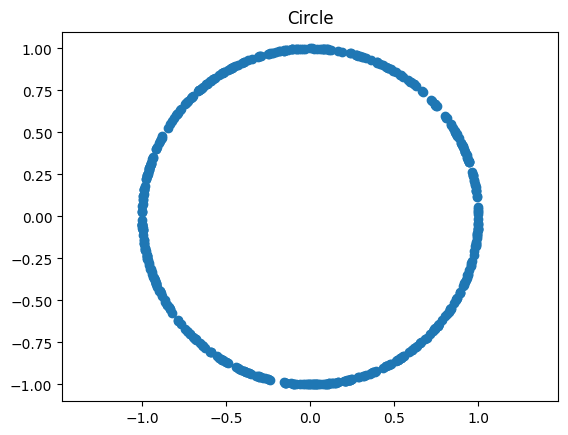

Circle
+---------------+--------------------------------------+-------------+
|   # of Points |   Mean Error in C over 10 iterations |     Std Dev |
+===============+======================================+=============+
|            10 |                          0.181038    | 0.121643    |
+---------------+--------------------------------------+-------------+
|            20 |                          0.0505706   | 0.0577004   |
+---------------+--------------------------------------+-------------+
|            30 |                          0.0124792   | 0.00612575  |
+---------------+--------------------------------------+-------------+
|            40 |                          0.00729995  | 0.00476935  |
+---------------+--------------------------------------+-------------+
|            50 |                          0.00302727  | 0.00217073  |
+---------------+--------------------------------------+-------------+
|            60 |                          0.0024955   | 0.00162447  |

In [ ]:
## Circle
# the unit circle
import numpy as np
import math
import matplotlib.pyplot as plt

theta_list = [np.random.uniform(0, 2*math.pi) for _ in range(500)]
xs=[]; ys=[]
for theta in theta_list:
    xs.append(math.cos(theta))
    ys.append(math.sin(theta))
plt.scatter(xs, ys)
plt.title('Circle')
plt.axis('equal')
plt.show()

k = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200]

c_errs = []
c_stds = []

for i in k:
    c_err = []

    for j in range(10):
        theta_list = [np.random.uniform(0, 2*math.pi) for _ in range(i)]
        theta_list.sort()

        p_k = []
        for theta in theta_list:
            p_k.append((math.cos(theta), math.sin(theta)))

        c_err.append(abs(exact_half(p_k,(1,1))[1]))

    c_errs.append(np.mean(c_err))
    c_stds.append(np.std(c_err, ddof=1))

from tabulate import tabulate

headers = [
    "# of Points",
    "Mean Error in C over 10 iterations",
    "Std Dev"
]

rows = list(zip(k, c_errs, c_stds))

print("Circle")
print(tabulate(rows, headers=headers, tablefmt="grid"))

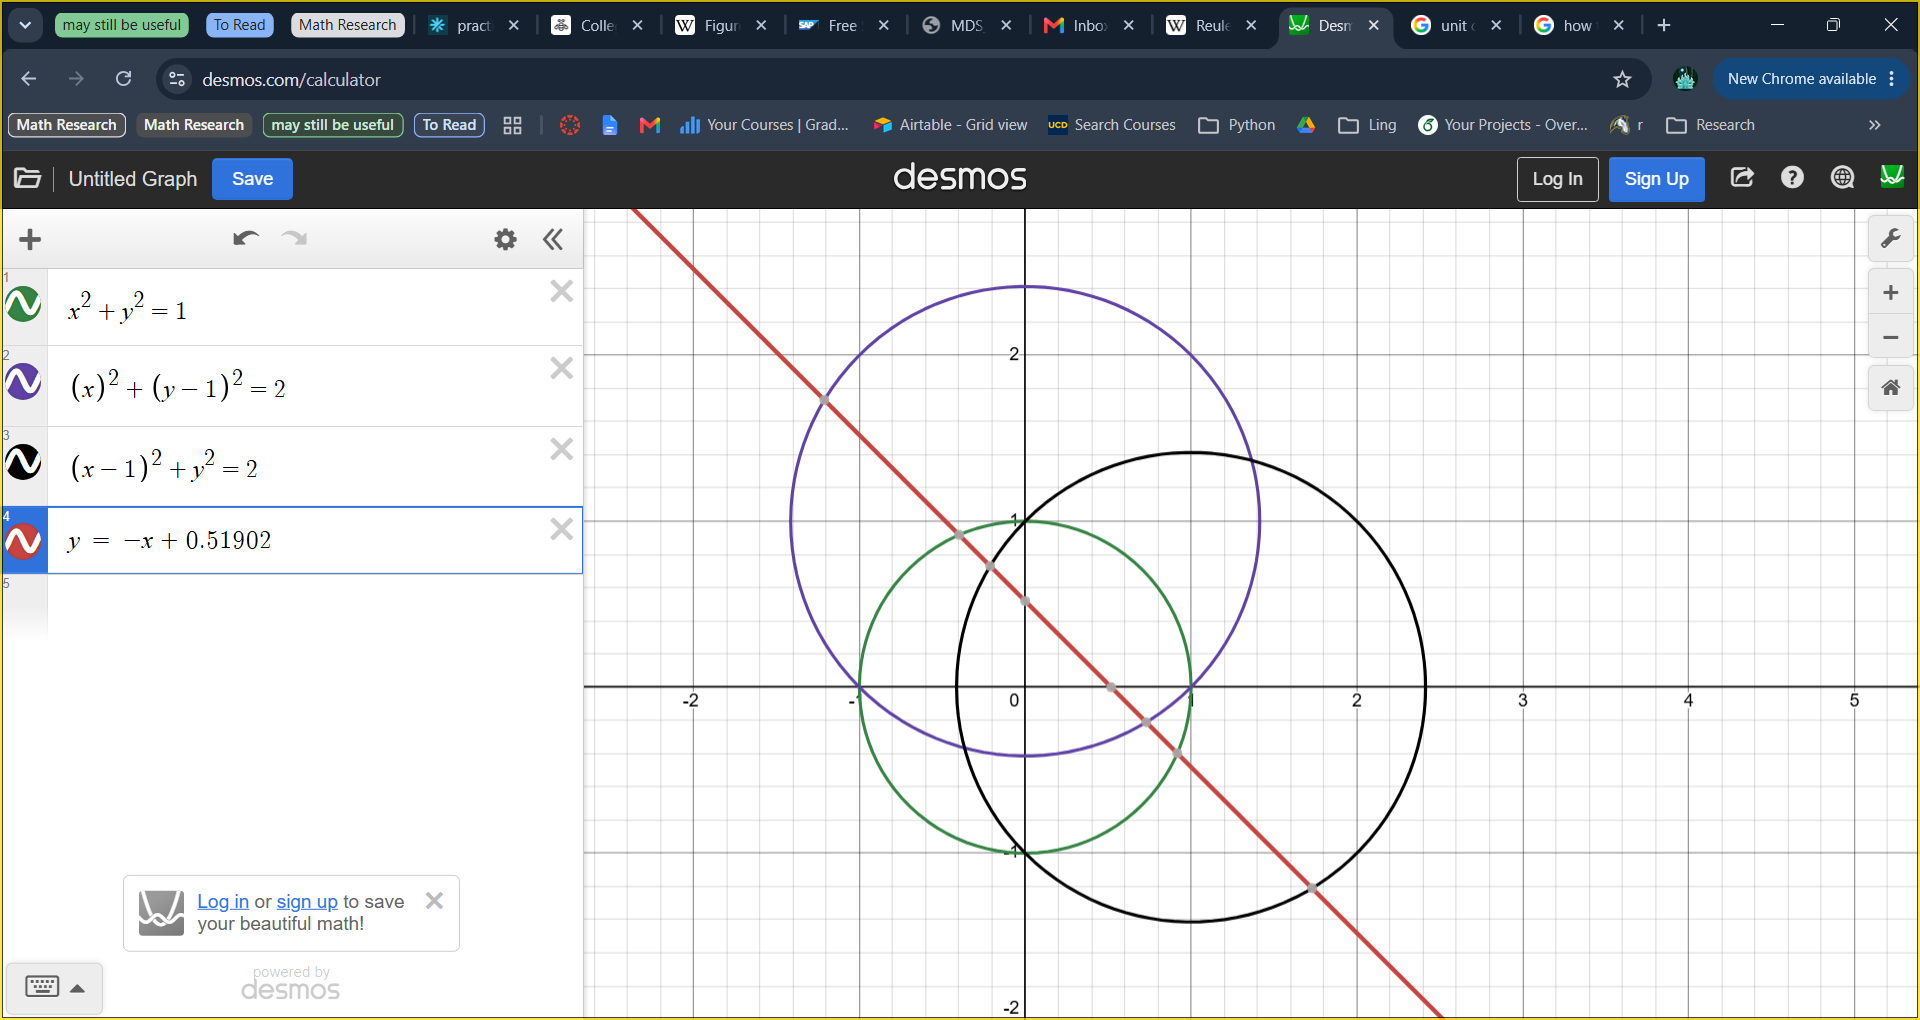

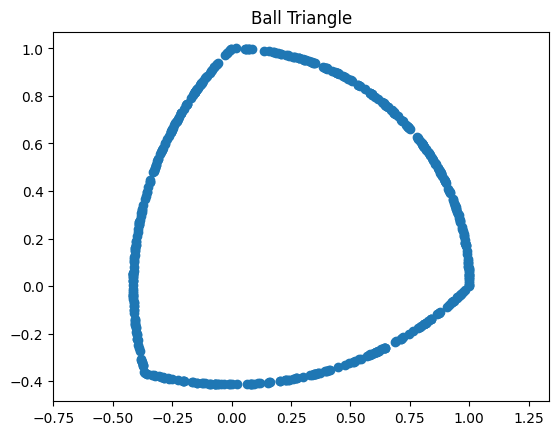

1.5137657818566157
Ball Triangle
+---------------+--------------------------------+-------------+---------------------------+
|   # of Points |   Mean in C over 10 iterations |     Std Dev |   c value in one instance |
+===============+================================+=============+===========================+
|            10 |                       0.437627 | 0.158689    |                  0.566662 |
+---------------+--------------------------------+-------------+---------------------------+
|            20 |                       0.516956 | 0.0501521   |                  0.501041 |
+---------------+--------------------------------+-------------+---------------------------+
|            30 |                       0.512539 | 0.0174956   |                  0.524029 |
+---------------+--------------------------------+-------------+---------------------------+
|            40 |                       0.518274 | 0.00669502  |                  0.512686 |
+---------------+--------------------

In [ ]:
## Ball Triangle
## Based on triangle with vertices (0,0), (1,0), and (0,1)
# functions of the circles are x^2+y^2 =1, (x-1)^2+y^2 = 2, and x^2 + (y-1)^2 = 2
import matplotlib.pyplot as plt
import math
theta_list = [np.random.uniform(0, 2*math.pi) for _ in range(500)]
xs = []
ys = []
for theta in theta_list:
    if theta >= 0 and theta <(2/3) *math.pi:
        xs.append((math.cos((3/4)*theta)))
        ys.append(math.sin((3/4)*theta))
    elif theta >= (2/3)*math.pi and theta <(4/3)*math.pi:
        xs.append(math.sqrt(2)*(math.cos(theta/2 + (5/12)*math.pi))+1)
        ys.append(math.sqrt(2)*math.sin(theta/2 + (5/12)*math.pi))
    elif theta >= (4/3)*math.pi and theta < 2* math.pi:
        xs.append(math.sqrt(2)*(math.cos(theta/2 + (9/12)*math.pi)))
        ys.append(math.sqrt(2)*math.sin(theta/2 + (9/12)*math.pi)+1)
plt.scatter(xs, ys)
plt.title('Ball Triangle')
plt.axis('equal')
plt.show()

k = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 500, 600, 1000, 2000, 5000]

c_errs = []
c_stds = []
cs = []

for i in k:
    c_err = []

    for j in range(10):
        theta_list = [np.random.uniform(0, 2*math.pi) for _ in range(i)]
        theta_list.sort()

        p_k = []

        for theta in theta_list:
            if theta >= 0 and theta < (2/3)*math.pi:
                p_k.append((math.cos((3/4)*theta), math.sin((3/4)*theta)))
            elif theta >= (2/3)*math.pi and theta < (4/3)*math.pi:
                p_k.append((
                    math.sqrt(2)*(math.cos(theta/2 + (5/12)*math.pi))+1,
                    math.sqrt(2)*math.sin(theta/2 + (5/12)*math.pi)
                ))
            else:
                p_k.append((
                    math.sqrt(2)*(math.cos(theta/2 + (9/12)*math.pi)),
                    math.sqrt(2)*math.sin(theta/2 + (9/12)*math.pi)+1
                ))

        c = exact_half(p_k,(1,1))[1]
        c_err.append(abs(c))

        if j == 0:
            cs.append(c)

    c_errs.append(np.mean(c_err))
    c_stds.append(np.std(c_err, ddof=1))

print(area(p_k))

headers = [
    "# of Points",
    "Mean in C over 10 iterations",
    "Std Dev",
    "c value in one instance"
]

rows = list(zip(k, c_errs, c_stds, cs))

print("Ball Triangle")
print(tabulate(rows, headers=headers, tablefmt="grid"))


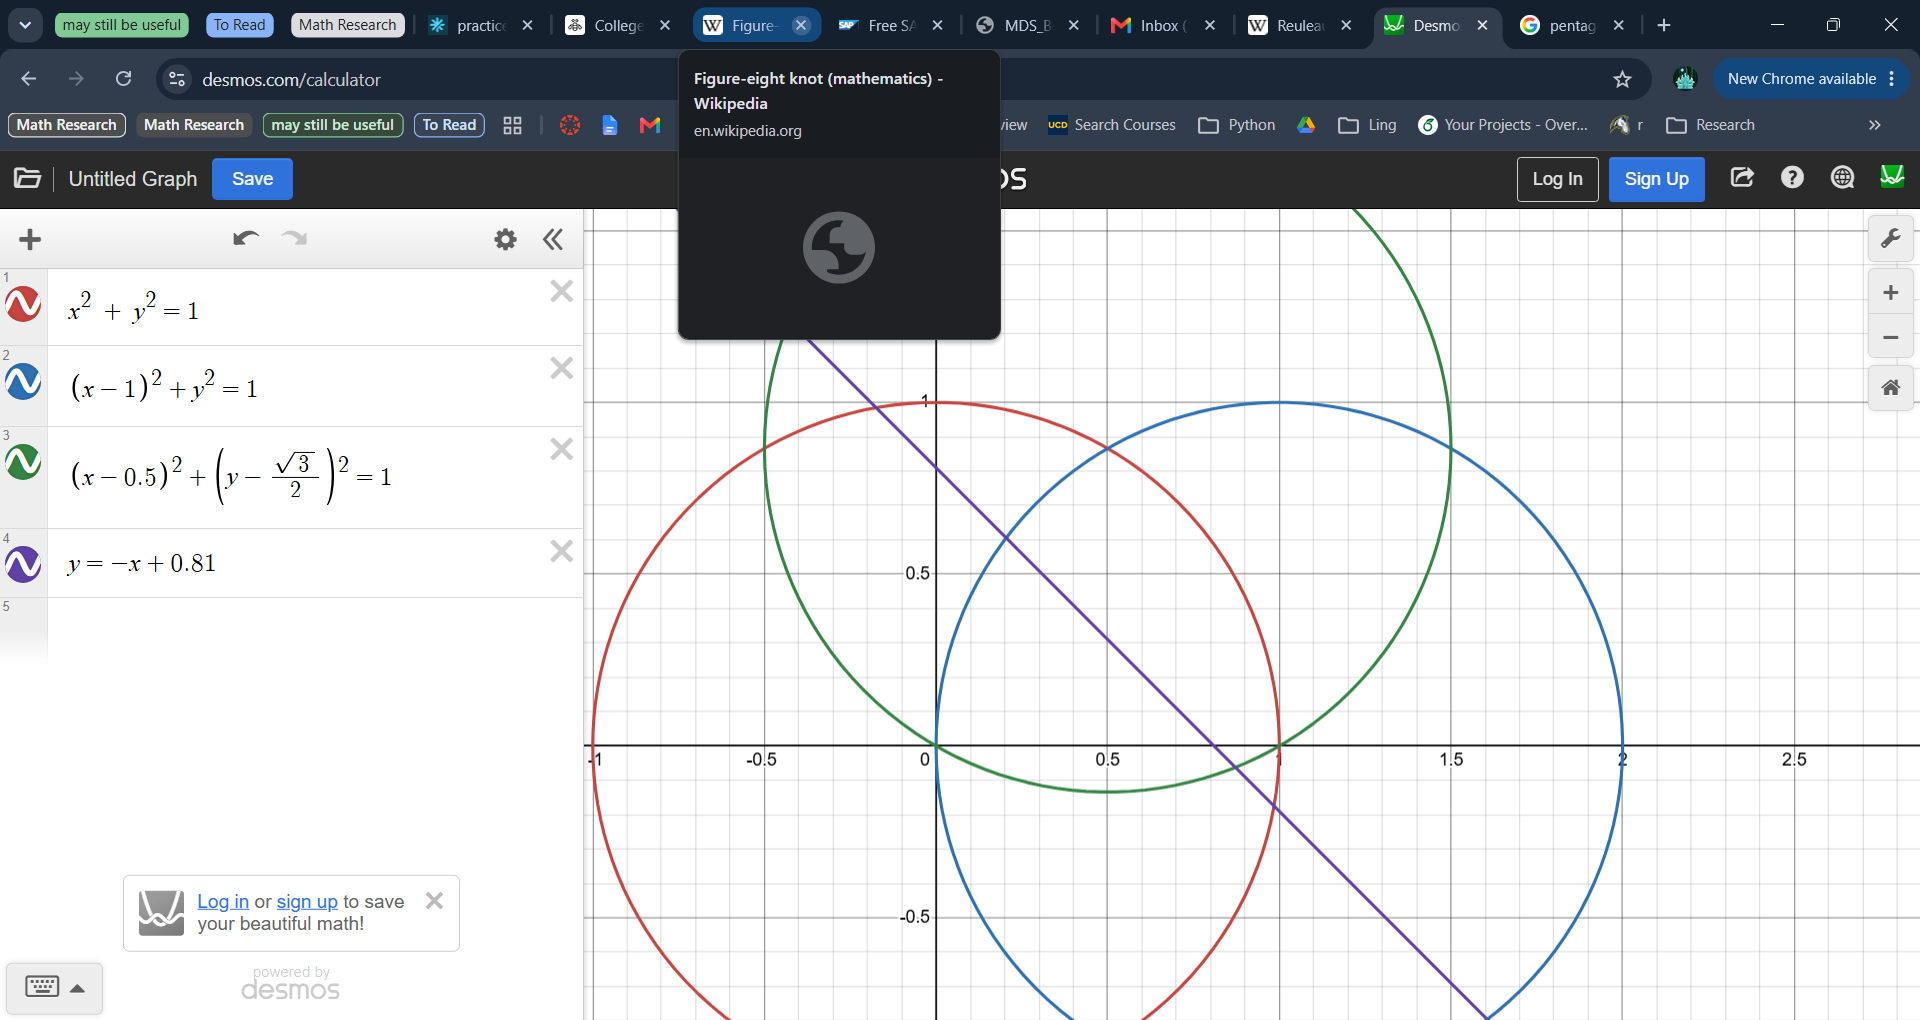

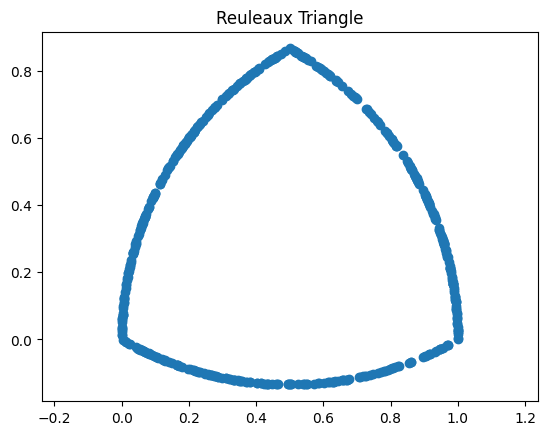

Reuleaux Triangle
+---------------+--------------------------------+-------------+-----------------------------------------+
|   # of Points |   Mean in C over 10 iterations |     Std Dev |   Value of c in one particular instance |
+===============+================================+=============+=========================================+
|            10 |                       0.832933 | 0.0916394   |                                0.828915 |
+---------------+--------------------------------+-------------+-----------------------------------------+
|            20 |                       0.806632 | 0.0174258   |                                0.808733 |
+---------------+--------------------------------+-------------+-----------------------------------------+
|            30 |                       0.812641 | 0.0143904   |                                0.814127 |
+---------------+--------------------------------+-------------+-----------------------------------------+
|            40 |  

In [ ]:
## Reuleaux Triangle
# using triangle with vertices (0,0), (1,0), and (0.5, sqrt(3)/2)
import matplotlib.pyplot as plt
theta_list = [np.random.uniform(0, 2*math.pi) for _ in range(500)]
xs = []
ys = []
for theta in theta_list:
    if theta >= 0 and theta <(2/3) *math.pi:
        xs.append((math.cos(theta/2)))
        ys.append(math.sin(theta/2))
    elif theta >= (2/3)*math.pi and theta <(4/3)*math.pi:
        xs.append((math.cos(theta/2 + math.pi/3)+1))
        ys.append(math.sin(theta/2 + math.pi/3))
    elif theta >= (4/3)*math.pi and theta < 2* math.pi:
        xs.append((math.cos(theta/2 + (2/3)*math.pi)+0.5))
        ys.append(math.sin(theta/2 + (2/3)*math.pi)+math.sqrt(3)/2)
plt.scatter(xs, ys)
plt.title('Reuleaux Triangle')
plt.axis('equal')
plt.show()


k = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200]

c_errs = []
c_stds = []
cs = []

for i in k:
    c_err = []

    for j in range(10):
        theta_list = [np.random.uniform(0, 2*math.pi) for _ in range(i)]
        theta_list.sort()

        p_k = []

        for theta in theta_list:
            if theta >= 0 and theta < (2/3)*math.pi:
                p_k.append((math.cos(theta/2), math.sin(theta/2)))
            elif theta >= (2/3)*math.pi and theta < (4/3)*math.pi:
                p_k.append((
                    math.cos(theta/2 + math.pi/3)+1,
                    math.sin(theta/2 + math.pi/3)
                ))
            else:
                p_k.append((
                    math.cos(theta/2 + (2/3)*math.pi)+0.5,
                    math.sin(theta/2 + (2/3)*math.pi)+math.sqrt(3)/2
                ))

        c = exact_half(p_k,(1,1))[1]
        c_err.append(c)

        if j == 0:
            cs.append(c)

    c_errs.append(np.mean(c_err))
    c_stds.append(np.std(c_err, ddof=1))

headers = [
    "# of Points",
    "Mean in C over 10 iterations",
    "Std Dev",
    "Value of c in one particular instance"
]

rows = list(zip(k, c_errs, c_stds, cs))

print("Reuleaux Triangle")
print(tabulate(rows, headers=headers, tablefmt="grid"))

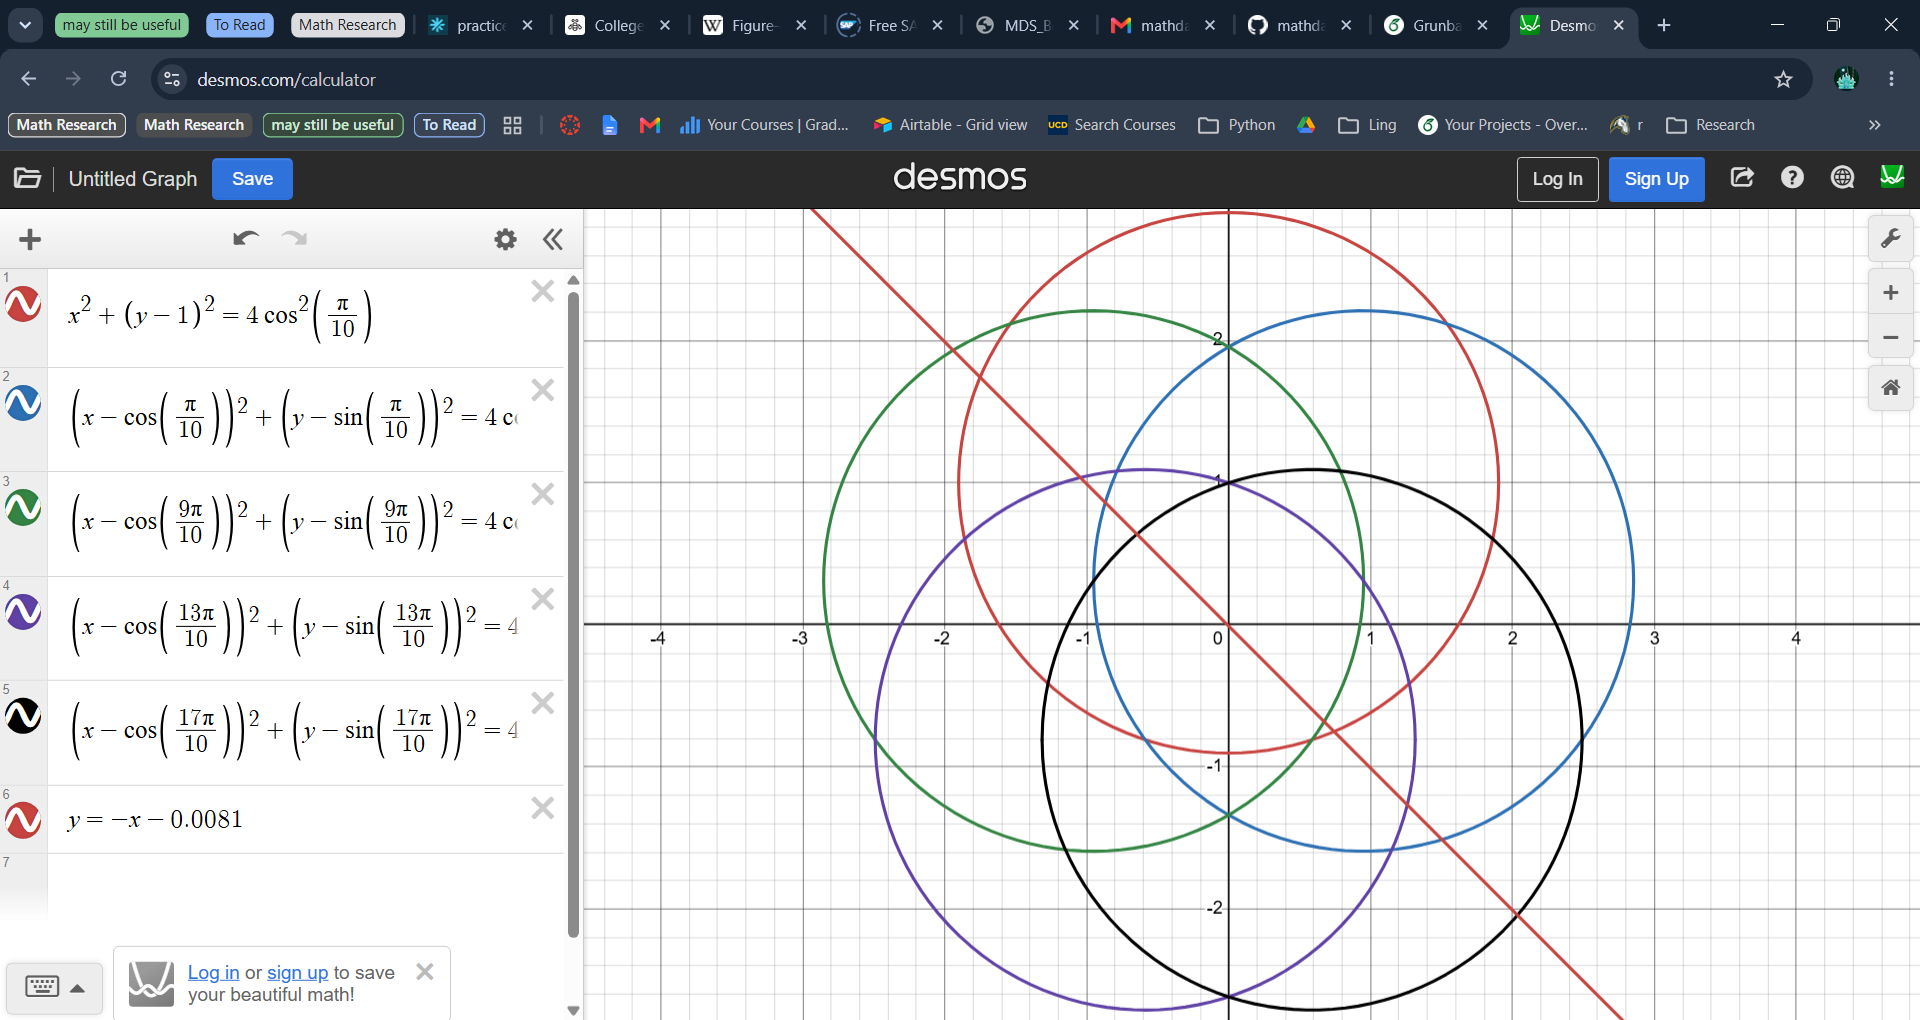

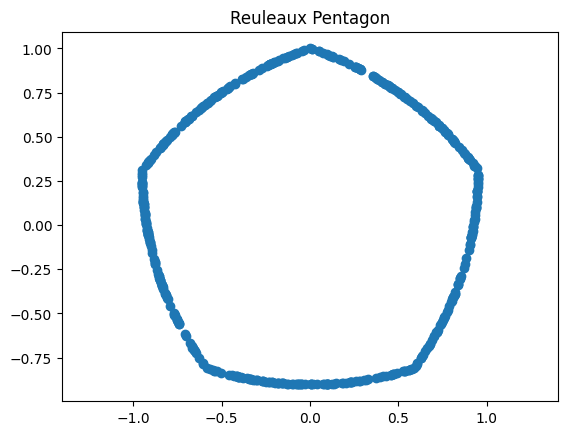

Reuleaux Pentagon
+---------------+--------------------------------+-------------+------------------------------------------+
|   # of Points |   Mean in C over 10 iterations |     Std Dev |   Value of c in one particular iteration |
+===============+================================+=============+==========================================+
|            10 |                    -0.0431087  | 0.216998    |                             -0.181155    |
+---------------+--------------------------------+-------------+------------------------------------------+
|            20 |                     0.00771368 | 0.0358327   |                              0.0374697   |
+---------------+--------------------------------+-------------+------------------------------------------+
|            30 |                    -0.00448367 | 0.0213577   |                              0.0196141   |
+---------------+--------------------------------+-------------+------------------------------------------+
|         

In [ ]:
## Reauleaux Pentagon
# made by chosing vertices of pentagon from the unit circle. The vertices are at theta = pi/10, pi/2, 9pi/10, 13pi/10, and 17pi/10

import matplotlib.pyplot as plt
theta_list = [np.random.uniform(0, 2*math.pi) for _ in range(500)]
xs = []
ys = []
r= 2*math.cos(math.pi/10)
for theta in theta_list:
    if theta >= 0 and theta <(2/5) *math.pi:
        xs.append(r*(math.cos(theta/2+(2/10)*math.pi))+math.cos(13*math.pi/10))
        ys.append(r*math.sin(theta/2+(2/10)*math.pi)+math.sin(13*math.pi/10))
    elif theta >= (2/5)*math.pi and theta <(4/5)*math.pi:
        xs.append(r*(math.cos(theta/2 + (4/10)*math.pi))+math.cos(17*math.pi/10))
        ys.append(r*math.sin(theta/2 + (4/10)*math.pi)+math.sin(17*math.pi/10))
    elif theta >= (4/5)*math.pi and theta < (6/5)* math.pi:
        xs.append(r*(math.cos(theta/2 + (6/10)*math.pi))+math.cos(math.pi/10))
        ys.append(r*math.sin(theta/2 + (6/10)*math.pi)+math.sin(math.pi/10))
    elif theta >= (6/5)*math.pi and theta < (8/5) * math.pi:
        xs.append(r*(math.cos(theta/2 + (8/10)*math.pi))+math.cos(math.pi/2))
        ys.append(r*math.sin(theta/2 + (8/10)*math.pi)+math.sin(math.pi/2))
    elif theta >= (8/5)*math.pi and theta<2*math.pi:
        xs.append(r*(math.cos(theta/2 + math.pi))+math.cos(9*math.pi/10))
        ys.append(r*math.sin(theta/2 + math.pi)+math.sin(9*math.pi/10))
plt.scatter(xs, ys)
plt.title('Reuleaux Pentagon')
plt.axis('equal')
plt.show()


k = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 300, 400, 500, 1000]

c_errs = []
c_stds = []
cs = []

r = 2*math.cos(math.pi/10)

for i in k:
    c_err = []

    for j in range(10):
        theta_list = [np.random.uniform(0, 2*math.pi) for _ in range(i)]
        theta_list.sort()

        p_k = []

        for theta in theta_list:
            if theta >= 0 and theta < (2/5)*math.pi:
                p_k.append((
                    r*(math.cos(theta/2+(2/10)*math.pi))+math.cos(13*math.pi/10),
                    r*math.sin(theta/2+(2/10)*math.pi)+math.sin(13*math.pi/10)
                ))
            elif theta >= (2/5)*math.pi and theta < (4/5)*math.pi:
                p_k.append((
                    r*(math.cos(theta/2+(4/10)*math.pi))+math.cos(17*math.pi/10),
                    r*math.sin(theta/2+(4/10)*math.pi)+math.sin(17*math.pi/10)
                ))
            elif theta >= (4/5)*math.pi and theta < (6/5)*math.pi:
                p_k.append((
                    r*(math.cos(theta/2+(6/10)*math.pi))+math.cos(math.pi/10),
                    r*math.sin(theta/2+(6/10)*math.pi)+math.sin(math.pi/10)
                ))
            elif theta >= (6/5)*math.pi and theta < (8/5)*math.pi:
                p_k.append((
                    r*(math.cos(theta/2+(8/10)*math.pi))+math.cos(math.pi/2),
                    r*math.sin(theta/2+(8/10)*math.pi)+math.sin(math.pi/2)
                ))
            else:
                p_k.append((
                    r*(math.cos(theta/2+math.pi))+math.cos(9*math.pi/10),
                    r*math.sin(theta/2+math.pi)+math.sin(9*math.pi/10)
                ))

        c = exact_half(p_k,(1,1))[1]
        c_err.append(c)

        if j == 0:
            cs.append(c)

    c_errs.append(np.mean(c_err))
    c_stds.append(np.std(c_err, ddof=1))

headers = [
    "# of Points",
    "Mean in C over 10 iterations",
    "Std Dev",
    "Value of c in one particular iteration"
]

rows = list(zip(k, c_errs, c_stds, cs))

print("Reuleaux Pentagon")
print(tabulate(rows, headers=headers, tablefmt="grid"))